<a href="https://colab.research.google.com/github/latentfield/EV-Price-Prediction/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import koreanize_matplotlib
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error


# 2. Exploratory Data Analysis (EDA)

In [2]:
data = pd.read_csv('train.csv')
data

,ID,제조사,모델,차량상태,배터리용량,구동방식,주행거리(km),보증기간(년),사고이력,연식(년),가격(백만원)
0,TRAIN_0000,P사,TayGTS,Nearly New,86.077,AWD,13642,0,No,2,159.66
1,TRAIN_0001,K사,Niro,Nearly New,56.000,FWD,10199,6,No,0,28.01
2,TRAIN_0002,A사,eT,Brand New,91.200,AWD,2361,7,No,0,66.27
3,TRAIN_0003,A사,RSeTGT,Nearly New,NaN,AWD,21683,3,No,0,99.16
4,TRAIN_0004,B사,i5,Pre-Owned,61.018,AWD,178205,1,No,0,62.02
...,...,...,...,...,...,...,...,...,...,...,...
7492,TRAIN_7492,H사,ION5,Brand New,NaN,AWD,3773,10,No,0,35.95
7493,TRAIN_7493,B사,i3,Pre-Owned,46.000,RWD,135411,2,No,0,23.40
7494,TRAIN_7494,P사,TayCT,Brand New,NaN,AWD,1363,2,No,0,120.00
7495,TRAIN_7495,B사,i3,Nearly New,56.000,RWD,39445,6,No,2,24.00


In [3]:
data.columns

Index(['ID', '제조사', '모델', '차량상태', '배터리용량', '구동방식', '주행거리(km)', '보증기간(년)',
       '사고이력', '연식(년)', '가격(백만원)'],
      dtype='str')

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
배터리용량,4786.0,69.397187,15.283635,46.0,56.359,68.125,78.227,99.80
주행거리(km),7497.0,44287.979458,55204.064386,3.0,5465.000,17331.000,61252.000,199827.00
보증기간(년),7497.0,4.960918,3.155342,0.0,2.000,5.000,8.000,10.00
연식(년),7497.0,0.222489,0.569232,0.0,0.000,0.000,0.000,2.00
가격(백만원),7497.0,62.331949,36.646759,9.0,34.390,56.000,80.050,161.09


# 결측치 확인

In [5]:
data.isna().sum()

ID             0
제조사            0
모델             0
차량상태           0
배터리용량       2711
구동방식           0
주행거리(km)       0
보증기간(년)        0
사고이력           0
연식(년)          0
가격(백만원)        0
dtype: int64

# 결측치 처리를 위한 배터리용량 칼럼 분석

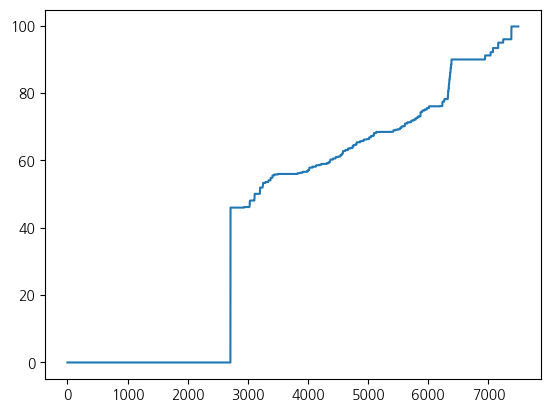

In [6]:
plt.plot(sorted(data['배터리용량'].fillna(0).tolist()))

In [7]:
data[data.describe().T.index].fillna(0).corr()

,배터리용량,주행거리(km),보증기간(년),연식(년),가격(백만원)
배터리용량,1.000000,0.238585,-0.262924,0.166370,0.043591
주행거리(km),0.238585,1.000000,-0.664071,-0.089586,-0.035488
보증기간(년),-0.262924,-0.664071,1.000000,0.035294,-0.349962
연식(년),0.166370,-0.089586,0.035294,1.000000,-0.058455
가격(백만원),0.043591,-0.035488,-0.349962,-0.058455,1.000000


* 배터리용량과 numerical 칼럼들의 상관관계는 약하다고 판단.

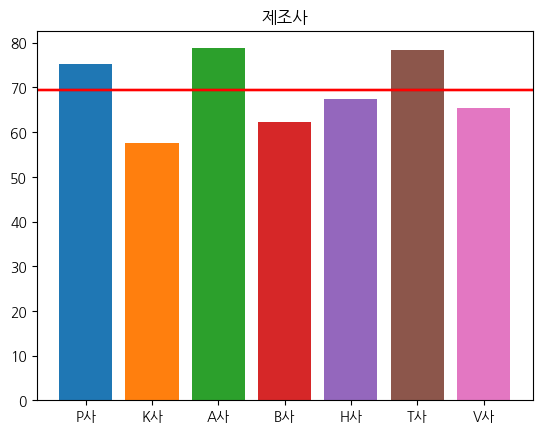

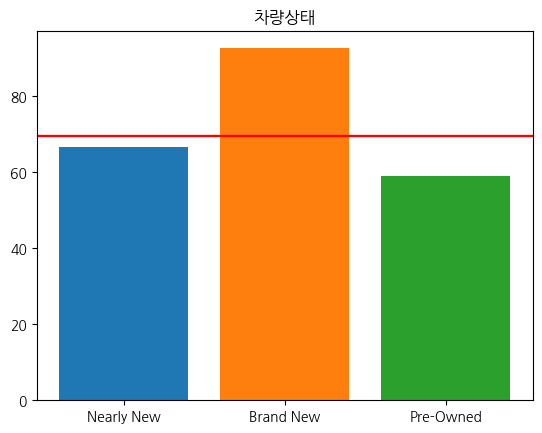

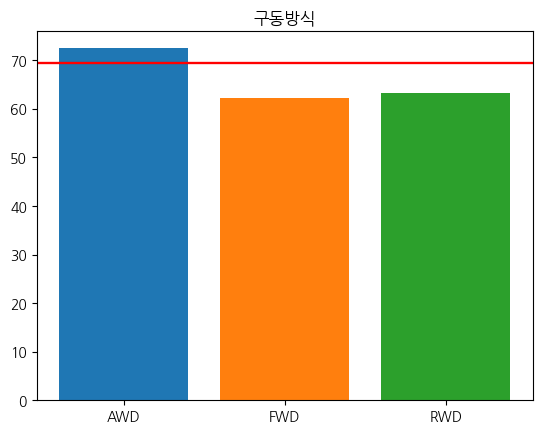

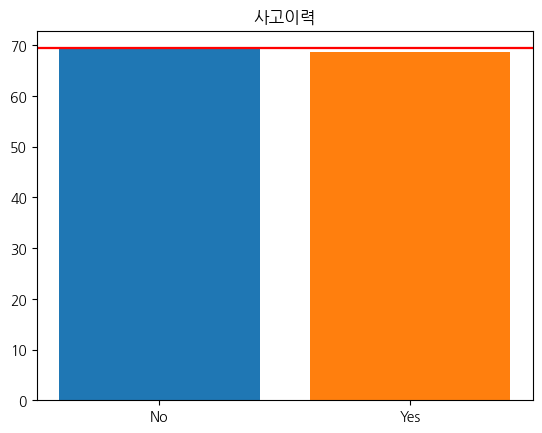

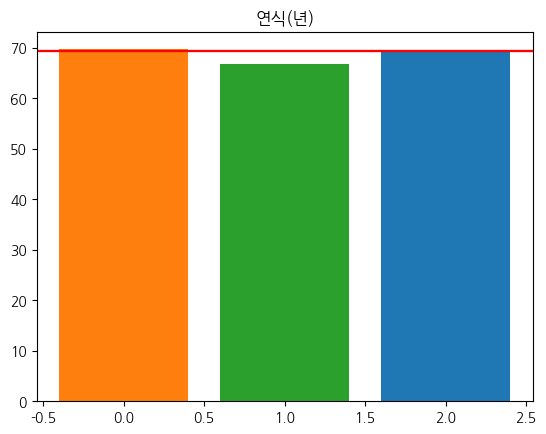

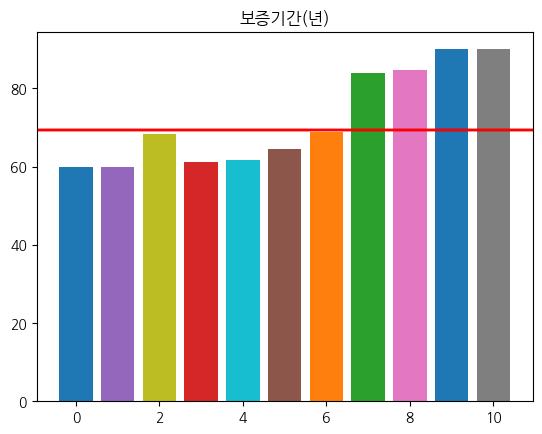

In [8]:
for idx, column_key in enumerate(['제조사', '차량상태', '구동방식', '사고이력', '연식(년)', '보증기간(년)']):
    for key in data[column_key].unique().tolist():
        plt.bar(key, data[data[column_key] == key]['배터리용량'].mean())
        plt.axhline(y=data['배터리용량'].mean(), color ='red')

    plt.axhline(y=data['배터리용량'].mean(), color='red')
    plt.title(column_key)
    plt.show()

배터리용량은

1. 보증기간이 7년 이상이면 유의미하게 길다.
2. brand-new일 경우 배터리용량이 크다.

In [9]:
display(data[data['차량상태']=='Brand New'].describe().T)
display(data[data['차량상태']!='Brand New'].describe().T)

,count,mean,std,min,25%,50%,75%,max
배터리용량,1072.0,92.586567,3.357944,90.00,90.00,90.00,95.00,99.80
주행거리(km),3380.0,4935.953550,2897.745303,3.00,2372.75,4980.00,7440.75,9999.00
보증기간(년),3380.0,7.312130,2.407674,2.00,7.00,8.00,9.00,10.00
연식(년),3380.0,0.000000,0.000000,0.00,0.00,0.00,0.00,0.00
가격(백만원),3380.0,65.092287,34.653946,16.56,38.98,59.98,80.09,161.09


,count,mean,std,min,25%,50%,75%,max
배터리용량,3714.0,62.703860,9.884803,46.0,56.00,61.994,69.253,92.16
주행거리(km),4117.0,76595.447899,56810.649644,10004.0,30057.00,49850.000,123350.000,199827.00
보증기간(년),4117.0,3.030605,2.259745,0.0,1.00,3.000,5.000,8.00
연식(년),4117.0,0.405149,0.718391,0.0,0.00,0.000,1.000,2.00
가격(백만원),4117.0,60.065749,38.060008,9.0,27.83,51.250,79.300,160.52


In [10]:
print(data[data['차량상태']=='Brand New']['보증기간(년)'].mean())
print(data[data['차량상태']!='Brand New']['보증기간(년)'].mean())

7.312130177514793
3.03060480932718


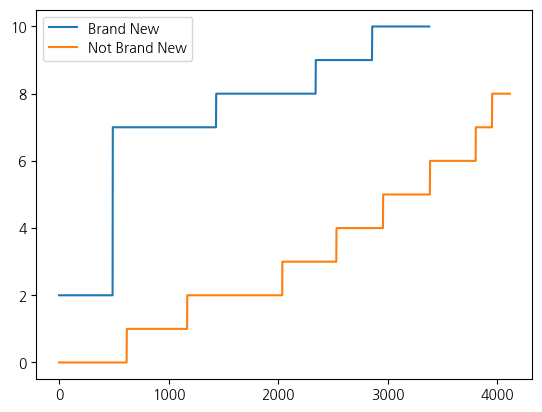

In [11]:
plt.plot(sorted(data[data['차량상태']=='Brand New']['보증기간(년)'].tolist()), label='Brand New')
plt.plot(sorted(data[data['차량상태']!='Brand New']['보증기간(년)'].tolist()), label='Not Brand New')
plt.legend(['Brand New', 'Not Brand New'])
plt.show()


Brand-new인 차량 대부분이 보증 기간이 7년 이상이다!

# 배터리 용량 결측치 처리 결론:
보증기간 7년 이상 / 7년 미만을 기준으로
각각의 평균값으로 처리함.

# Data Process

In [12]:
train_data = pd.read_csv('train.csv').drop(columns=['ID'])
submit_test_data = pd.read_csv('test.csv').drop(columns=['ID'])


In [13]:
numeric_cols = ['주행거리(km)', '보증기간(년)', '연식(년)']
for col in numeric_cols:
    train_data[col].fillna(train_data[col].median(), inplace=True)
    submit_test_data[col].fillna(submit_test_data[col].median(), inplace=True)

categorical_cols = ['제조사', '차량상태', '구동방식', '사고이력']
for col in categorical_cols:
    train_data[col].fillna(train_data[col].mode()[0], inplace=True)
    submit_test_data[col].fillna(submit_test_data[col].mode()[0], inplace=True)

train_data['배터리용량'].fillna(-1, inplace=True)
submit_test_data['배터리용량'].fillna(-1, inplace=True)

upper7_train = train_data[train_data['보증기간(년)']>=7]['배터리용량'].mean()
lower7_train = train_data[train_data['보증기간(년)']<7]['배터리용량'].mean()

upper7_test = submit_test_data[submit_test_data['보증기간(년)']>=7]['배터리용량'].mean()
lower7_test = submit_test_data[submit_test_data['보증기간(년)']>=7]['배터리용량'].mean()

def fill_battery(row, upper7, lower7):
    if row['배터리용량'] == -1:
        return upper7 if row['보증기간(년)'] >= 7 else lower7
    return row['배터리용량']

train_data['배터리용량'] = train_data.apply(lambda row: fill_battery(row, upper7_train, lower7_train), axis=1)
submit_test_data['배터리용량'] = submit_test_data.apply(lambda row: fill_battery(row, upper7_test, lower7_test), axis=1)

/tmp/ipykernel_37008/3133810687.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  train_data[col].fillna(train_data[col].median(), inplace=True)
/tmp/ipykernel_37008/3133810687.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace metho

In [14]:
encoder = LabelEncoder()
train_data['모델'] = encoder.fit_transform(train_data['모델'].astype(str))  # 문자열 → 숫자로 변환
submit_test_data['모델'] = encoder.transform(submit_test_data['모델'].astype(str))

for col in categorical_cols:
    train_data[col] = encoder.fit_transform(train_data[col].astype(str))
    submit_test_data[col] = encoder.transform(submit_test_data[col].astype(str))
    train_data[col] = encoder.fit_transform(train_data[col])
    submit_test_data[col] = encoder.transform(submit_test_data[col])

In [15]:
X = train_data.drop(columns=['가격(백만원)'])
y = train_data['가격(백만원)']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
print(X_train.dtypes)

제조사           int64
모델            int64
차량상태          int64
배터리용량       float64
구동방식          int64
주행거리(km)      int64
보증기간(년)       int64
사고이력          int64
연식(년)         int64
dtype: object


# 모델 학습

In [17]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_valid)

rmse_rf = np.sqrt(mean_squared_error(y_valid, y_pred_rf))
print(f"Random Forest RMSE: {rmse_rf}")

Random Forest RMSE: 1.6160456929665894


In [18]:
print("실제 가격 (y_valid) 분포:")
print(y_valid.describe())

print("\n예측 가격 (y_pred) 분포:")
print(pd.Series(y_pred_rf).describe())

print(f"\nValidation RMSE: {rmse_rf:.4f} (백만원 단위)")

실제 가격 (y_valid) 분포:
count    1500.000000
mean       62.773573
std        37.079838
min         9.000000
25%        34.237500
50%        58.680000
75%        80.212500
max       161.090000
Name: 가격(백만원), dtype: float64

예측 가격 (y_pred) 분포:
count    1500.000000
mean       62.749458
std        36.985488
min        13.171100
25%        34.104225
50%        58.850000
75%        80.034175
max       160.728600
dtype: float64

Validation RMSE: 1.6160 (백만원 단위)


# 결과물 출력

In [19]:
final_pred = rf_model.predict(submit_test_data)

submission = pd.DataFrame({
    'ID': pd.read_csv('test.csv')['ID'],
    '가격(백만원)': final_pred
})

submission.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' successfully generated")

Submission file 'submission.csv' successfully generated
